<a href="https://colab.research.google.com/github/Jirtus-sanasam/MLP-Diabetes/blob/main/Diabetes22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('/content/diabetes_data2.csv')
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [ ]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)

In [ ]:
# Imputing Null Value with KNNImputer
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)
df[cols] = knn_imputer.fit_transform(df[cols])

In [ ]:
# Cap outliers using IQR
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    return df

for col in df.columns[:-1]:  # exclude target
    df = cap_outliers(df, col)

In [ ]:
# FEATURE ENGINEERING

# --- 1. Interaction Features ---
df['Glucose_BMI'] = df['Glucose'] * df['BMI']
df['Glucose_Insulin'] = df['Glucose'] * df['Insulin']
df['BMI_Age'] = df['BMI'] * df['Age']
df['Insulin_SkinThickness'] = df['Insulin'] * df['SkinThickness']

# --- 2. Ratio Features (avoid division by zero) ---
df['Glucose_Insulin_Ratio'] = df['Glucose'] / (df['Insulin'] + 1e-6)
df['BMI_Age_Ratio'] = df['BMI'] / (df['Age'] + 1e-6)

# --- 3. Polynomial Features ---
df['Glucose_sq'] = df['Glucose'] ** 2
df['BMI_sq'] = df['BMI'] ** 2
df['Age_sq'] = df['Age'] ** 2

# --- 4. Age Binning ---
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young', 'Middle', 'Senior', 'Elderly']
)
# One-hot encoding with integer output
df = pd.get_dummies(df, columns=['Age_Group'], drop_first=True, dtype=int)

# --- 5. BMI Category ---
df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df = pd.get_dummies(df, columns=['BMI_Category'], drop_first=True, dtype=int)

# --- 6. Glucose Category ---
df['Glucose_Level'] = pd.cut(
    df['Glucose'],
    bins=[0, 99, 125, 300],
    labels=['Normal', 'Prediabetes', 'Diabetes']
)

df = pd.get_dummies(df, columns=['Glucose_Level'], drop_first=True, dtype=int)

# --- 7. Insulin Resistance (HOMA-IR) ---
df['HOMA_IR'] = (df['Glucose'] * df['Insulin']) / 405
# --- 8. Pregnancy Risk Flag ---
df['High_Pregnancies'] = (df['Pregnancies'] > 3).astype(int)

# --- 9. Log Transform (handle skewness) ---
df['Log_Insulin'] = np.log1p(df['Insulin'])
df['Log_DiabetesPedigreeFunction'] = np.log1p(df['DiabetesPedigreeFunction'])

# --- 10. Composite Risk Score ---
df['Risk_Score'] = (
    (df['Glucose'] / 100) +
    (df['BMI'] / 25) +
    (df['Age'] / 50) +
    (df['DiabetesPedigreeFunction'])
)

# --- 11. Final Safety Check (convert any leftover bool → int) ---
bool_cols = df.select_dtypes(include='bool').columns
if not bool_cols.empty:
    for col in bool_cols.unique(): # Iterate over unique column names
        # Ensure we are only trying to convert actual boolean columns that might still exist
        if df[col].dtype == 'bool':
            df[col] = df[col].astype(int)
# --- 12. Verify Data Types ---
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Pregnancies                   768 non-null    float64
 1   Glucose                       768 non-null    float64
 2   BloodPressure                 768 non-null    float64
 3   SkinThickness                 768 non-null    float64
 4   Insulin                       768 non-null    float64
 5   BMI                           768 non-null    float64
 6   DiabetesPedigreeFunction      768 non-null    float64
 7   Age                           768 non-null    float64
 8   Outcome                       768 non-null    int64  
 9   Glucose_BMI                   768 non-null    float64
 10  Glucose_Insulin               768 non-null    float64
 11  BMI_Age                       768 non-null    float64
 12  Insulin_SkinThickness         768 non-null    float64
 13  Gluco

In [ ]:
X = df.drop('Outcome', axis=1)
Y = df['Outcome']

# Use only RFECV selected features
selected_features = ['Glucose', 'Glucose_BMI', 'Glucose_Insulin', 'BMI_Age',
                     'Insulin_SkinThickness', 'BMI_Age_Ratio', 'Glucose_sq',
                     'BMI_sq', 'HOMA_IR', 'Risk_Score']

X = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", dict(pd.Series(y_train).value_counts()))
print("After SMOTE: ", dict(pd.Series(y_train_sm).value_counts()))

Before SMOTE: {0: np.int64(400), 1: np.int64(214)}
After SMOTE:  {0: np.int64(400), 1: np.int64(400)}


Best Threshold (F1-optimized): 0.25

=== Base MLP (Tuned Threshold) ===
Accuracy : 0.7338
ROC-AUC  : 0.8309
F1-Score : 0.7092

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.63      0.75       100
           1       0.57      0.93      0.71        54

    accuracy                           0.73       154
   macro avg       0.76      0.78      0.73       154
weighted avg       0.81      0.73      0.74       154



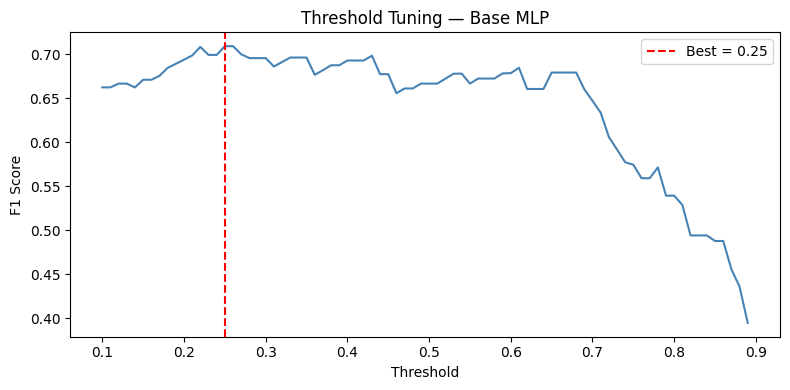

In [ ]:
# ============================================================
# CELL 1: Base MLP with Fixed Hyperparameters + Threshold Tuning
# ============================================================
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, f1_score, confusion_matrix,
                             roc_curve, precision_recall_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Best hyperparameters (from your tuning) ---
best_params = {
    'hidden_layer_sizes': (150, 16),
    'activation': 'relu',
    'learning_rate_init': 0.0064983077805908914,
    'alpha': 0.009879943193542264,
    'batch_size': 32,
    'max_iter': 500,
    'early_stopping': True,
    'validation_fraction': 0.1,
    'random_state': 42
}

base_mlp = MLPClassifier(**best_params)
base_mlp.fit(X_train_sm, y_train_sm)

# --- Threshold Tuning ---
y_prob_val = base_mlp.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_prob_val >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold (F1-optimized): {best_thresh:.2f}")

y_pred_tuned = (y_prob_val >= best_thresh).astype(int)

print("\n=== Base MLP (Tuned Threshold) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_val):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_tuned):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

# --- Plot Threshold vs F1 ---
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='steelblue')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best = {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Tuning — Base MLP')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 2: Cross-Validation on Base MLP
# ============================================================
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Rebuild pipeline so scaler + SMOTE isn't data-leaking across folds
# We evaluate on original (non-SMOTE) splits here
cv_scores = cross_val_score(
    MLPClassifier(**best_params),
    X_train_scaled, y_train,          # use pre-scaled train data
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("=== 5-Fold CV — Base MLP ===")
print(f"ROC-AUC per fold : {np.round(cv_scores, 4)}")
print(f"Mean ± Std       : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

=== 5-Fold CV — Base MLP ===
ROC-AUC per fold : [0.8672 0.8384 0.8642 0.8422 0.8161]
Mean ± Std       : 0.8456 ± 0.0187


In [ ]:
# ============================================================
# CELL 3: Deep Ensemble MLP
# ============================================================

class DeepEnsembleMLP:
    """
    Train N independently-seeded MLPs on SMOTE-balanced data.
    Aggregate by averaging predicted probabilities (soft voting).
    """
    def __init__(self, n_estimators=10, base_params=None):
        self.n_estimators = n_estimators
        self.base_params  = base_params or {}
        self.models       = []

    def fit(self, X, y):
        self.models = []
        for seed in range(self.n_estimators):
            params = {**self.base_params, 'random_state': seed}
            m = MLPClassifier(**params)
            m.fit(X, y)
            self.models.append(m)
        return self

    def predict_proba(self, X):
        probs = np.array([m.predict_proba(X)[:, 1] for m in self.models])
        return probs.mean(axis=0)          # shape: (n_samples,)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


ensemble_params = {k: v for k, v in best_params.items() if k != 'random_state'}

deep_ensemble = DeepEnsembleMLP(n_estimators=10, base_params=ensemble_params)
deep_ensemble.fit(X_train_sm, y_train_sm)

# --- Threshold tuning for ensemble too ---
y_prob_ens = deep_ensemble.predict_proba(X_test_scaled)

f1_ens  = [f1_score(y_test, (y_prob_ens >= t).astype(int)) for t in thresholds]
best_thresh_ens = thresholds[np.argmax(f1_ens)]
print(f"Best Threshold (Ensemble, F1-optimized): {best_thresh_ens:.2f}")

y_pred_ens = (y_prob_ens >= best_thresh_ens).astype(int)

print("\n=== Deep Ensemble MLP (Tuned Threshold) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_ens):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_ens):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_ens):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_ens))

Best Threshold (Ensemble, F1-optimized): 0.30

=== Deep Ensemble MLP (Tuned Threshold) ===
Accuracy : 0.7273
ROC-AUC  : 0.8294
F1-Score : 0.7000

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.63      0.75       100
           1       0.57      0.91      0.70        54

    accuracy                           0.73       154
   macro avg       0.75      0.77      0.72       154
weighted avg       0.80      0.73      0.73       154



In [ ]:
# ============================================================
# CELL 4: Cross-Validation on Deep Ensemble
# ============================================================

def ensemble_cv_roc_auc(X, y, n_estimators=10, base_params=None, n_splits=5):
    """Manual stratified CV for the ensemble (sklearn CV doesn't wrap custom classes)."""
    skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs   = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        # SMOTE inside fold to prevent leakage
        smote_fold = SMOTE(random_state=42)
        X_tr_sm, y_tr_sm = smote_fold.fit_resample(X_tr, y_tr)

        ens = DeepEnsembleMLP(n_estimators=n_estimators, base_params=base_params)
        ens.fit(X_tr_sm, y_tr_sm)
        prob = ens.predict_proba(X_val)
        auc  = roc_auc_score(y_val, prob)
        aucs.append(auc)
        print(f"  Fold {fold}: ROC-AUC = {auc:.4f}")
    return np.array(aucs)

print("=== 5-Fold CV — Deep Ensemble MLP ===")
ens_cv_scores = ensemble_cv_roc_auc(
    X_train_scaled, y_train.values,
    n_estimators=10,
    base_params=ensemble_params
)
print(f"\nMean ± Std : {ens_cv_scores.mean():.4f} ± {ens_cv_scores.std():.4f}")

=== 5-Fold CV — Deep Ensemble MLP ===
  Fold 1: ROC-AUC = 0.8805
  Fold 2: ROC-AUC = 0.8433
  Fold 3: ROC-AUC = 0.8799
  Fold 4: ROC-AUC = 0.8250
  Fold 5: ROC-AUC = 0.8095

Mean ± Std : 0.8477 ± 0.0287


In [ ]:
# ============================================================
# CELL 1: Imports & Base Learners Setup
# ============================================================
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               StackingClassifier, VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              classification_report, confusion_matrix, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Your best MLP params (base learner)
best_mlp_params = {
    'hidden_layer_sizes': (150, 16),
    'activation': 'relu',
    'learning_rate_init': 0.0064983077805908914,
    'alpha': 0.009879943193542264,
    'batch_size': 32,
    'max_iter': 500,
    'early_stopping': True,
    'validation_fraction': 0.1,
    'random_state': 42
}

In [ ]:
# ============================================================
# CELL 2: Define Base Learners
# ============================================================
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

base_learners = [
    ('mlp', MLPClassifier(**best_params)),

    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0
    )),

    ('lgbm', LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    )),

    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_split=5,
        random_state=42, n_jobs=-1
    )),

    ('gb', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42
    )),

    ('svm', SVC(
        C=1.0, kernel='rbf', probability=True,
        random_state=42
    ))
]

print("Base learners defined:")
for name, _ in base_learners:
    print(f"  ✓ {name}")

Base learners defined:
  ✓ mlp
  ✓ xgb
  ✓ lgbm
  ✓ rf
  ✓ gb
  ✓ svm


In [ ]:
# ============================================================
# CELL 2: Define Base Learners
# ============================================================
base_learners = [
    ('mlp', MLPClassifier(**best_mlp_params)),

    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0
    )),

    ('lgbm', LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    )),

    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_split=5,
        random_state=42, n_jobs=-1
    )),

    ('gb', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42
    )),

    ('svm', SVC(
        C=1.0, kernel='rbf', probability=True,
        random_state=42
    ))
]

print("Base learners defined:")
for name, _ in base_learners:
    print(f"  ✓ {name}")

Base learners defined:
  ✓ mlp
  ✓ xgb
  ✓ lgbm
  ✓ rf
  ✓ gb
  ✓ svm
